## Using Random Forest Regressor 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('complete')

complete


In [2]:
df = pd.read_csv('../data/owid-covid-data.csv')
df_uk = df[df['location'] == 'United Kingdom']
df_uk['date'] = pd.to_datetime(df_uk['date'])
df_uk = df_uk.sort_values('date')
df_uk = df_uk.dropna(subset=['new_cases_smoothed'])
df_uk = df_uk.reset_index(drop=True)

print(df_uk.shape)

(1669, 67)


In [3]:
df_ml = df_uk[['date', 'new_cases_smoothed']].copy()

for lag in range(1, 15):
    df_ml[f'lag_{lag}'] = df_ml['new_cases_smoothed'].shift(lag)

df_ml['target'] = df_ml['new_cases_smoothed'].shift(-14)

df_ml = df_ml.dropna()
df_ml = df_ml.reset_index(drop=True)

print(df_ml.shape)
print(df_ml.head())

(1641, 17)
        date  new_cases_smoothed  lag_1  lag_2  ...  lag_12  lag_13  lag_14  target
0 2020-01-24                 0.0    0.0    0.0  ...     0.0     0.0     0.0    0.14
1 2020-01-25                 0.0    0.0    0.0  ...     0.0     0.0     0.0    0.14
2 2020-01-26                 0.0    0.0    0.0  ...     0.0     0.0     0.0    2.86
3 2020-01-27                 0.0    0.0    0.0  ...     0.0     0.0     0.0    2.86
4 2020-01-28                 0.0    0.0    0.0  ...     0.0     0.0     0.0    2.86

[5 rows x 17 columns]


In [4]:
split = int(len(df_ml) * 0.8)

train = df_ml[:split]
test = df_ml[split:]

feature_cols = [f'lag_{i}' for i in range(1, 15)]

X_train = train[feature_cols]
y_train = train['target']

X_test = test[feature_cols]
y_test = test['target']

print(f'Training: {len(train)} rows')
print(f'Testing: {len(test)} rows')

Training: 1312 rows
Testing: 329 rows


In [5]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5

print(f'MAE: {mae:.0f} cases')
print(f'RMSE: {rmse:.0f} cases')

MAE: 764 cases
RMSE: 1112 cases


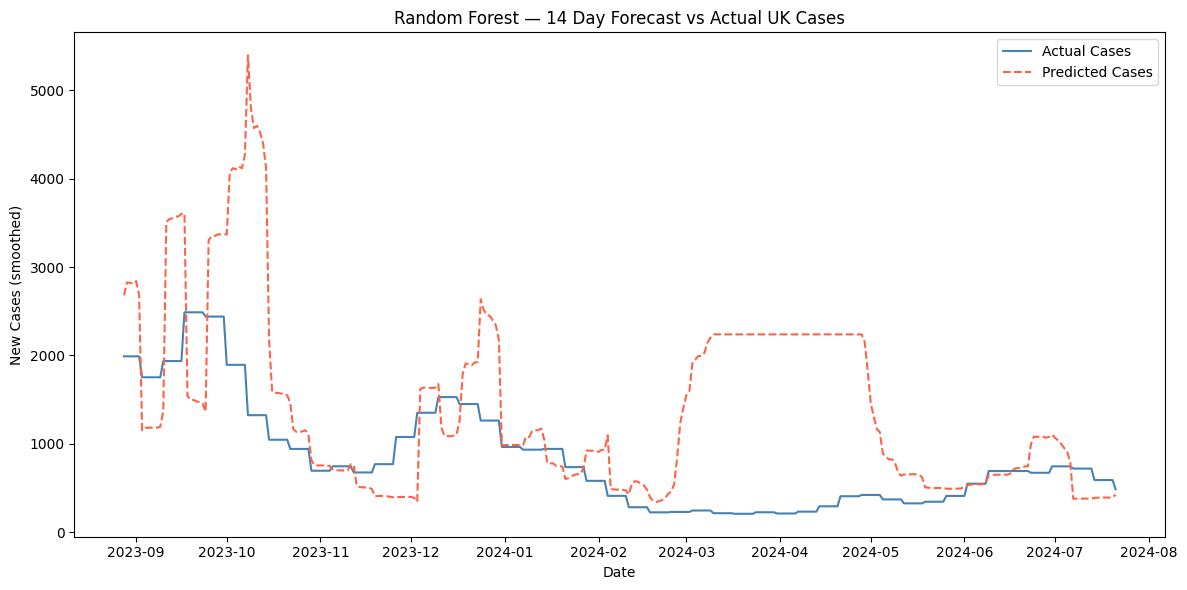

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(test['date'], y_test.values, label='Actual Cases', color='steelblue')
plt.plot(test['date'], predictions, label='Predicted Cases', color='tomato', linestyle='--')
plt.title('Random Forest — 14 Day Forecast vs Actual UK Cases')
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. ML vs SEIR Model Comparison

Two fundamentally different approaches to epidemic forecasting:
- **SEIR model** — mechanistic, based on disease biology and transmission dynamics
- **Random Forest** — data-driven, learns patterns purely from historical case data

In [7]:
print('Random Forest 14-day Forecasting Performance:')
print(f'MAE: {mae:.0f} cases per day')
print(f'RMSE: {rmse:.0f} cases per day')
print()
print('Context:')
print(f'Mean actual cases in test period: {y_test.mean():.0f}')
print(f'MAE as % of mean: {100*mae/y_test.mean():.1f}%')

Random Forest 14-day Forecasting Performance:
MAE: 764 cases per day
RMSE: 1112 cases per day

Context:
Mean actual cases in test period: 831
MAE as % of mean: 92.0%


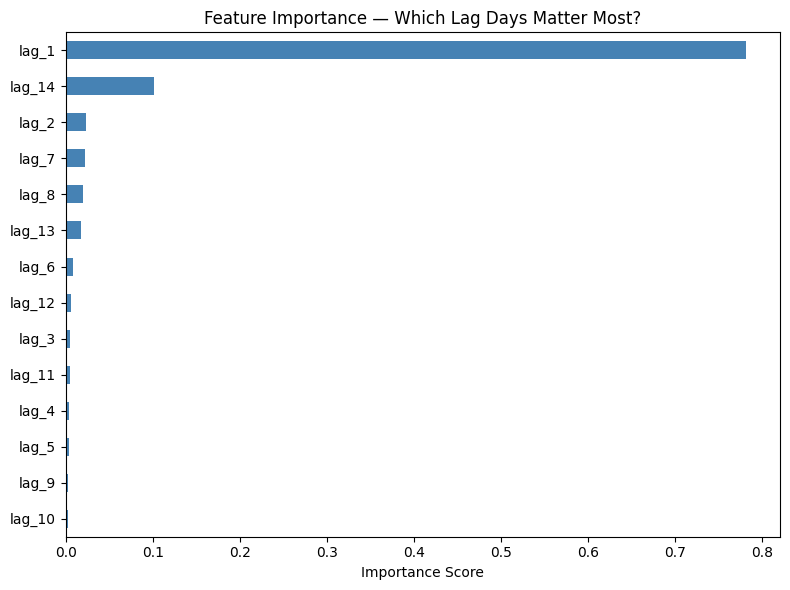

In [8]:
feature_importance = pd.Series(
    rf_model.feature_importances_, 
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Which Lag Days Matter Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Feature Importance Finding
Most important lags: lag_1 (most recent) and lag_14 (two weeks ago).
Middle lags are relatively less important — knowing today's cases and 
cases from exactly one forecast horizon ago captures most of the signal.
This suggests COVID case trends had a roughly 14-day cyclical pattern,
possibly reflecting weekly reporting patterns and incubation periods.